Day1 hands-on activity

##Conducting EDA

Import libraries (pandas, numpy, os, matplotlib, seaborn, ....)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read the dataset

[dataset link](https://www.kaggle.com/datasets/liyangng/restaurant-success-prediction)

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Restaurant_Success_Dataset.csv  


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("liyangng/restaurant-success-prediction")

# Load dataset
# The 'path' variable from kagglehub.dataset_download is the directory where the dataset files are located.
# We need to construct the full path to the CSV file within that directory.
file_name = "Restaurant_Success_Dataset.csv"
file_path = os.path.join(path, file_name)

Using Colab cache for faster access to the 'restaurant-success-prediction' dataset.


In [ ]:
import pandas as pd

df = pd.read_csv('Restaurant_Success_Dataset.csv')
df.head()

,Restaurant_ID,City,Cuisine_Type,Average_Meal_Price,Seating_Capacity,Years_in_Business,Google_Rating,Social_Media_Followers,Weekend_Reservations,Staff_Count,Delivery_Service,Marketing_Budget,Health_Inspection_Score,Annual_Revenue,Success_Label
0,R0001,Houston,Japanese,49,95,1,3.2,48576,202,33,Yes,3530,59,289190,0
1,R0002,San Francisco,Japanese,30,49,11,3.5,23749,246,46,No,9024,52,58888,1
2,R0003,Chicago,Japanese,24,40,16,3.2,42165,286,32,No,8607,85,1842602,1
3,R0004,San Francisco,Japanese,42,53,18,3.3,27225,236,22,Yes,17126,87,485413,1
4,R0005,San Francisco,Indian,44,60,16,3.2,34858,242,18,Yes,18768,74,1051830,1


**Check the following:**
1. The first rows of the dataset
2. Dataset shape
3. General info (data types, null values, ...)
4. Statistical info (min, max, median, mean, ...)
5. Bias in terms of target variable (balanced or unbalanced dataset)
6. The heatmap of correlation
8. Visualize the relationship between categorical values and the target
9. List and discus your insights

### 1. The first rows of the dataset (already displayed, reconfirming)

In [ ]:
df.head()

,Restaurant_ID,City,Cuisine_Type,Average_Meal_Price,Seating_Capacity,Years_in_Business,Google_Rating,Social_Media_Followers,Weekend_Reservations,Staff_Count,Delivery_Service,Marketing_Budget,Health_Inspection_Score,Annual_Revenue,Success_Label
0,R0001,Houston,Japanese,49,95,1,3.2,48576,202,33,Yes,3530,59,289190,0
1,R0002,San Francisco,Japanese,30,49,11,3.5,23749,246,46,No,9024,52,58888,1
2,R0003,Chicago,Japanese,24,40,16,3.2,42165,286,32,No,8607,85,1842602,1
3,R0004,San Francisco,Japanese,42,53,18,3.3,27225,236,22,Yes,17126,87,485413,1
4,R0005,San Francisco,Indian,44,60,16,3.2,34858,242,18,Yes,18768,74,1051830,1


### 2. Dataset shape

In [ ]:
df.shape

(1000, 15)

### 3. General info (data types, null values, ...)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Restaurant_ID            1000 non-null   object 
 1   City                     1000 non-null   object 
 2   Cuisine_Type             1000 non-null   object 
 3   Average_Meal_Price       1000 non-null   int64  
 4   Seating_Capacity         1000 non-null   int64  
 5   Years_in_Business        1000 non-null   int64  
 6   Google_Rating            1000 non-null   float64
 7   Social_Media_Followers   1000 non-null   int64  
 8   Weekend_Reservations     1000 non-null   int64  
 9   Staff_Count              1000 non-null   int64  
 10  Delivery_Service         1000 non-null   object 
 11  Marketing_Budget         1000 non-null   int64  
 12  Health_Inspection_Score  1000 non-null   int64  
 13  Annual_Revenue           1000 non-null   int64  
 14  Success_Label            

### 4. Statistical info (min, max, median, mean, ...)

In [ ]:
df.describe()

,Average_Meal_Price,Seating_Capacity,Years_in_Business,Google_Rating,Social_Media_Followers,Weekend_Reservations,Staff_Count,Marketing_Budget,Health_Inspection_Score,Annual_Revenue,Success_Label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,29.294000,84.684000,15.589000,3.696400,25094.227000,152.886000,26.902000,10578.363000,75.098000,1.066631e+06,0.681000
std,11.516171,36.899318,8.216056,0.730713,14585.542863,84.100975,12.987882,5666.931338,14.483928,5.512818e+05,0.466322
min,10.000000,20.000000,1.000000,2.500000,160.000000,10.000000,5.000000,511.000000,50.000000,5.137900e+04,0.000000
25%,19.000000,53.000000,9.000000,3.100000,12477.500000,79.000000,15.000000,5727.500000,63.000000,6.123378e+05,0.000000
50%,30.000000,84.000000,16.000000,3.700000,24780.000000,155.000000,27.000000,10714.000000,75.000000,1.071902e+06,1.000000
75%,39.000000,118.000000,23.000000,4.300000,37964.750000,224.000000,38.000000,15787.500000,88.000000,1.534667e+06,1.000000
max,49.000000,149.000000,29.000000,5.000000,49893.000000,299.000000,49.000000,19977.000000,99.000000,1.996918e+06,1.000000


### 5. Bias in terms of target variable (balanced or unbalanced dataset)

In [ ]:
df['Success_Label'].value_counts()

,count
Success_Label,
1,681
0,319


### 6. The heatmap of correlation

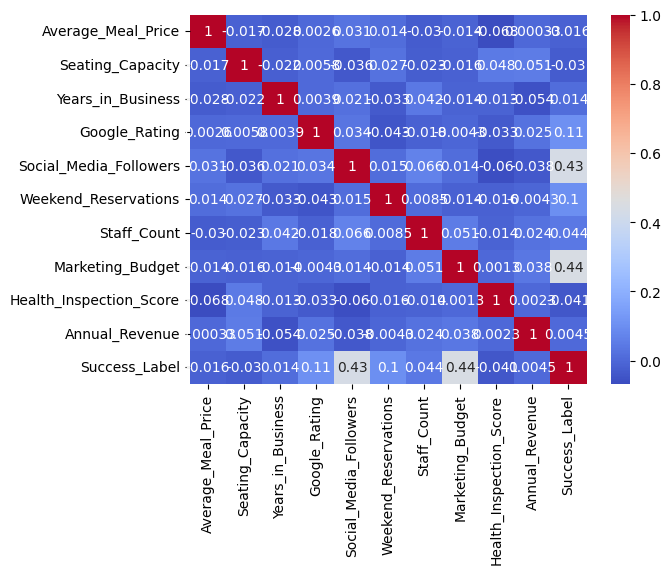

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.show()

### 7. Visualize the relationship between categorical values and the target

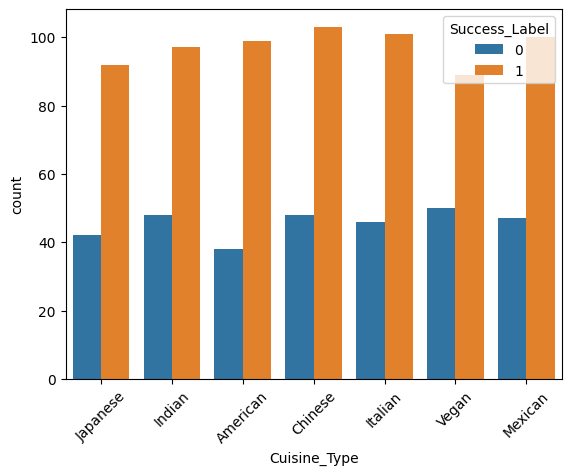

In [ ]:
sns.countplot(x='Cuisine_Type', hue='Success_Label', data=df)
plt.xticks(rotation=45)
plt.show()

### 8. List and discuss your insights


In [ ]:
# Bigger places and more marketing usually mean more success.
# Some locations and food types perform better than others.
# Good management is the main reason restaurants succeed.